In [1]:
import numpy as np
time_series1=np.load("E:/ADHD200/ICA_times_series_941.npy",allow_pickle=True)
label= np.load("E:/ADHD200/label_941.npy")
time_series2=np.load("E:/ADHD200/dict_learning_times_series_941.npy",allow_pickle=True)
label= np.load("E:/ADHD200/label_941.npy")
time_series = []
for i in range(len(time_series1)):
   time_series.append(np.concatenate((time_series1[i], time_series2[i]), axis=1))

In [2]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrices = correlation_measure.fit_transform( time_series)
X= correlation_matrices 

C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hp\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
X.shape

(941, 93, 93)

In [4]:
adhd = X[label == 1]
tc = X[label == 0]


In [5]:
adhd.shape

(357, 93, 93)

In [6]:
tc.shape

(584, 93, 93)

In [15]:
mean_adhd= np.mean(adhd, axis=0)
mean_tc= np.mean(tc, axis=0)

In [16]:
mean_adhd.shape, mean_tc.shape

((93, 93), (93, 93))

In [25]:
adhd[1]

array([[ 1.        ,  0.86770134,  0.39403146, ..., -0.25700582,
         0.54194073,  0.16292762],
       [ 0.86770134,  1.        ,  0.54952827, ..., -0.440754  ,
         0.6399795 ,  0.3138659 ],
       [ 0.39403146,  0.54952827,  1.        , ..., -0.88127574,
         0.83646293,  0.7495826 ],
       ...,
       [-0.25700582, -0.440754  , -0.88127574, ...,  1.        ,
        -0.72872177, -0.71334254],
       [ 0.54194073,  0.6399795 ,  0.83646293, ..., -0.72872177,
         1.        ,  0.81685958],
       [ 0.16292762,  0.3138659 ,  0.7495826 , ..., -0.71334254,
         0.81685958,  1.        ]])

In [26]:
 tc[1]

array([[1.        , 0.77085434, 0.34093749, ..., 0.3613275 , 0.34233971,
        0.32460133],
       [0.77085434, 1.        , 0.64462597, ..., 0.68672813, 0.17811543,
        0.22902335],
       [0.34093749, 0.64462597, 1.        , ..., 0.81446734, 0.1582477 ,
        0.25169526],
       ...,
       [0.3613275 , 0.68672813, 0.81446734, ..., 1.        , 0.10512404,
        0.16127331],
       [0.34233971, 0.17811543, 0.1582477 , ..., 0.10512404, 1.        ,
        0.9524452 ],
       [0.32460133, 0.22902335, 0.25169526, ..., 0.16127331, 0.9524452 ,
        1.        ]])

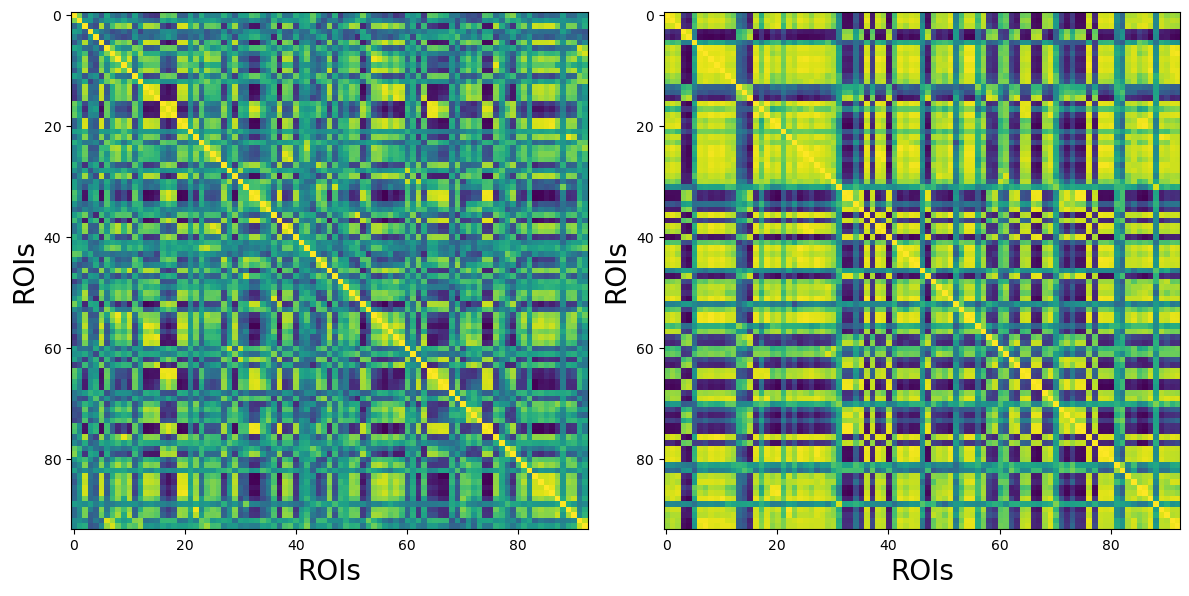

In [34]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

im1 = ax1.imshow(adhd[0], cmap='viridis', interpolation='nearest')
ax1.set_xlabel('ROIs',fontsize=20)
ax1.set_ylabel('ROIs',fontsize=20)
#fig.colorbar(im1, ax=ax1, label='Intensity', orientation='vertical')

im2 = ax2.imshow(tc[0], cmap='viridis', interpolation='nearest')
ax2.set_xlabel('ROIs',fontsize=20)
ax2.set_ylabel('ROIs',fontsize=20)
#fig.colorbar(im2, ax=ax2, label='Intensity', orientation='vertical')

plt.tight_layout()
plt.show()


In [47]:
pip install python-louvain

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 204.6/204.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9395 sha256=f7370d60343e9098e227e3db30d91f3818466c204f3265b51456117965fe1773
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\4d\7c\b6\79b198e4ec43f915fbdf967953d48b89a18893b12aa9df0ae2
Successfully built python-louvain
Note: you may need to restart the kernel to use updated packages.


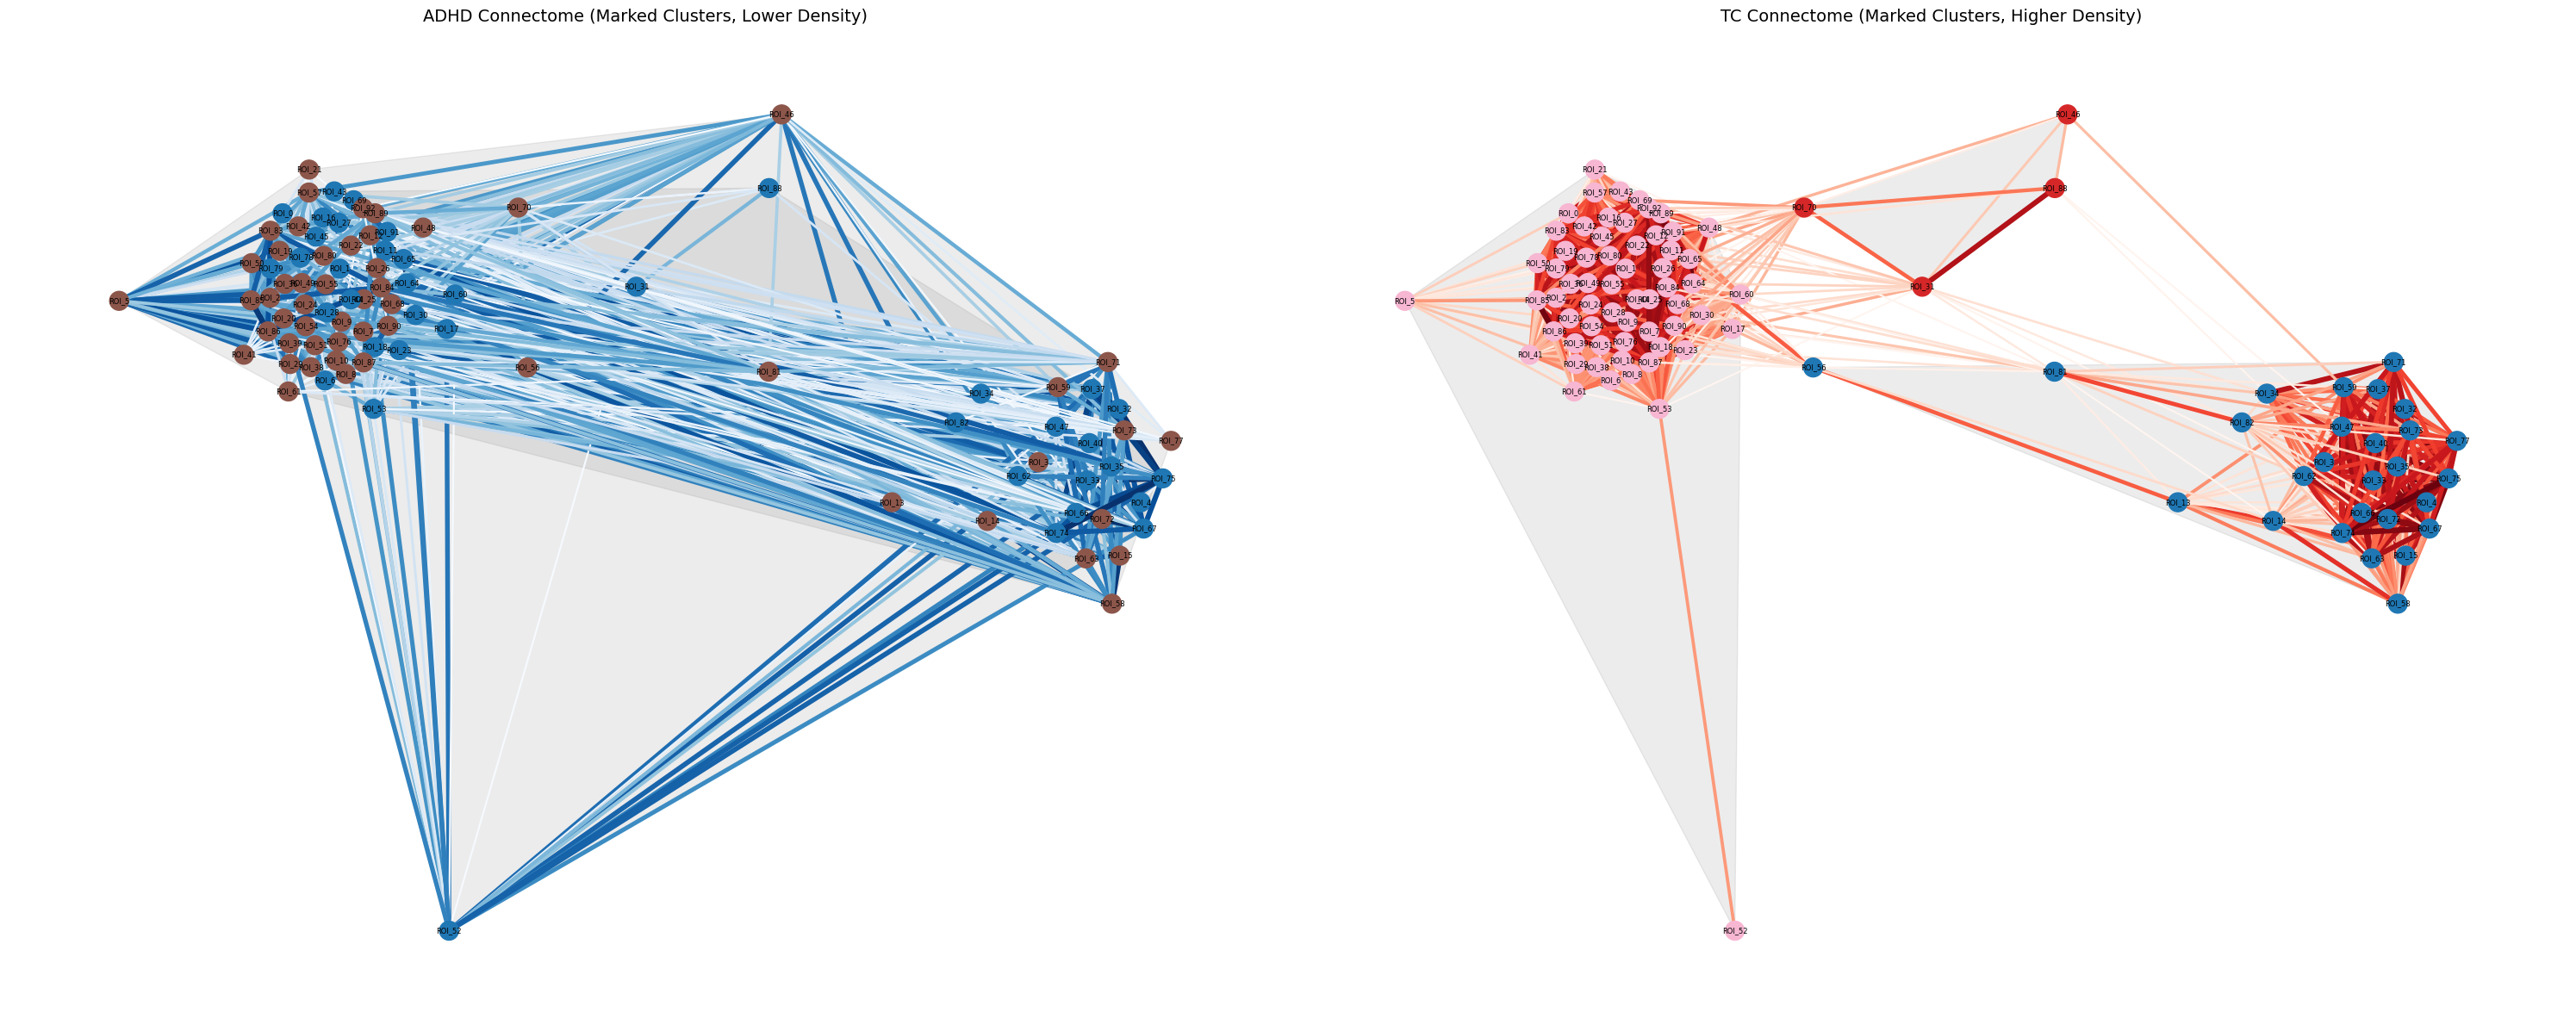

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import community as community_louvain  # pip install python-louvain
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon

# Use real matrices
adhd_0 = (adhd[0] + adhd[0].T) / 2
np.fill_diagonal(adhd_0, 0)
tc_0 = (tc[0] + tc_0.T) / 2
np.fill_diagonal(tc_0, 0)

roi_labels = [f"ROI_{i}" for i in range(93)]

def create_graph(matrix, threshold=0.3):
    G = nx.Graph()
    G.add_nodes_from(roi_labels)
    for i in range(93):
        for j in range(i+1, 93):
            weight = matrix[i, j]
            if weight > threshold:
                G.add_edge(roi_labels[i], roi_labels[j], weight=weight)
    return G

def get_communities(G):
    return community_louvain.best_partition(G)

def get_node_colors(partition, G):
    communities = list(set(partition.values()))
    color_map = {comm: plt.cm.tab20(i / len(communities)) for i, comm in enumerate(communities)}
    return [color_map[partition[node]] for node in G.nodes()]

def draw_cluster_boundaries(ax, pos, partition):
    community_groups = {}
    for node, comm in partition.items():
        community_groups.setdefault(comm, []).append(pos[node])

    for points in community_groups.values():
        if len(points) >= 3:
            points = np.array(points)
            hull = ConvexHull(points)
            polygon = Polygon(points[hull.vertices], closed=True, fill=True, alpha=0.15, color='gray', zorder=0)
            ax.add_patch(polygon)

# --- Create graphs and partitions ---
G_adhd = create_graph(adhd_0)
G_tc = create_graph(tc_0)
partition_adhd = get_communities(G_adhd)
partition_tc = get_communities(G_tc)

# --- Node positions (same for both for fair comparison) ---
pos = nx.spring_layout(G_tc, seed=42, k=0.25)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(30, 12))

# --- ADHD ---
colors_adhd = get_node_colors(partition_adhd, G_adhd)
edges = G_adhd.edges(data=True)
weights = [edata['weight'] * 5 for _, _, edata in edges]
draw_cluster_boundaries(axs[0], pos, partition_adhd)
nx.draw_networkx_nodes(G_adhd, pos, ax=axs[0], node_size=250, node_color=colors_adhd)
nx.draw_networkx_edges(G_adhd, pos, ax=axs[0], width=weights, edge_color=weights, edge_cmap=plt.cm.Blues)
nx.draw_networkx_labels(G_adhd, pos, ax=axs[0], font_size=6)
axs[0].set_title("ADHD Connectome (Marked Clusters, Lower Density)", fontsize=14)
axs[0].axis('off')

# --- TC ---
colors_tc = get_node_colors(partition_tc, G_tc)
edges = G_tc.edges(data=True)
weights = [edata['weight'] * 5 for _, _, edata in edges]
draw_cluster_boundaries(axs[1], pos, partition_tc)
nx.draw_networkx_nodes(G_tc, pos, ax=axs[1], node_size=250, node_color=colors_tc)
nx.draw_networkx_edges(G_tc, pos, ax=axs[1], width=weights, edge_color=weights, edge_cmap=plt.cm.Reds)
nx.draw_networkx_labels(G_tc, pos, ax=axs[1], font_size=6)
axs[1].set_title("TC Connectome (Marked Clusters, Higher Density)", fontsize=14)
axs[1].axis('off')

plt.tight_layout()
plt.show()


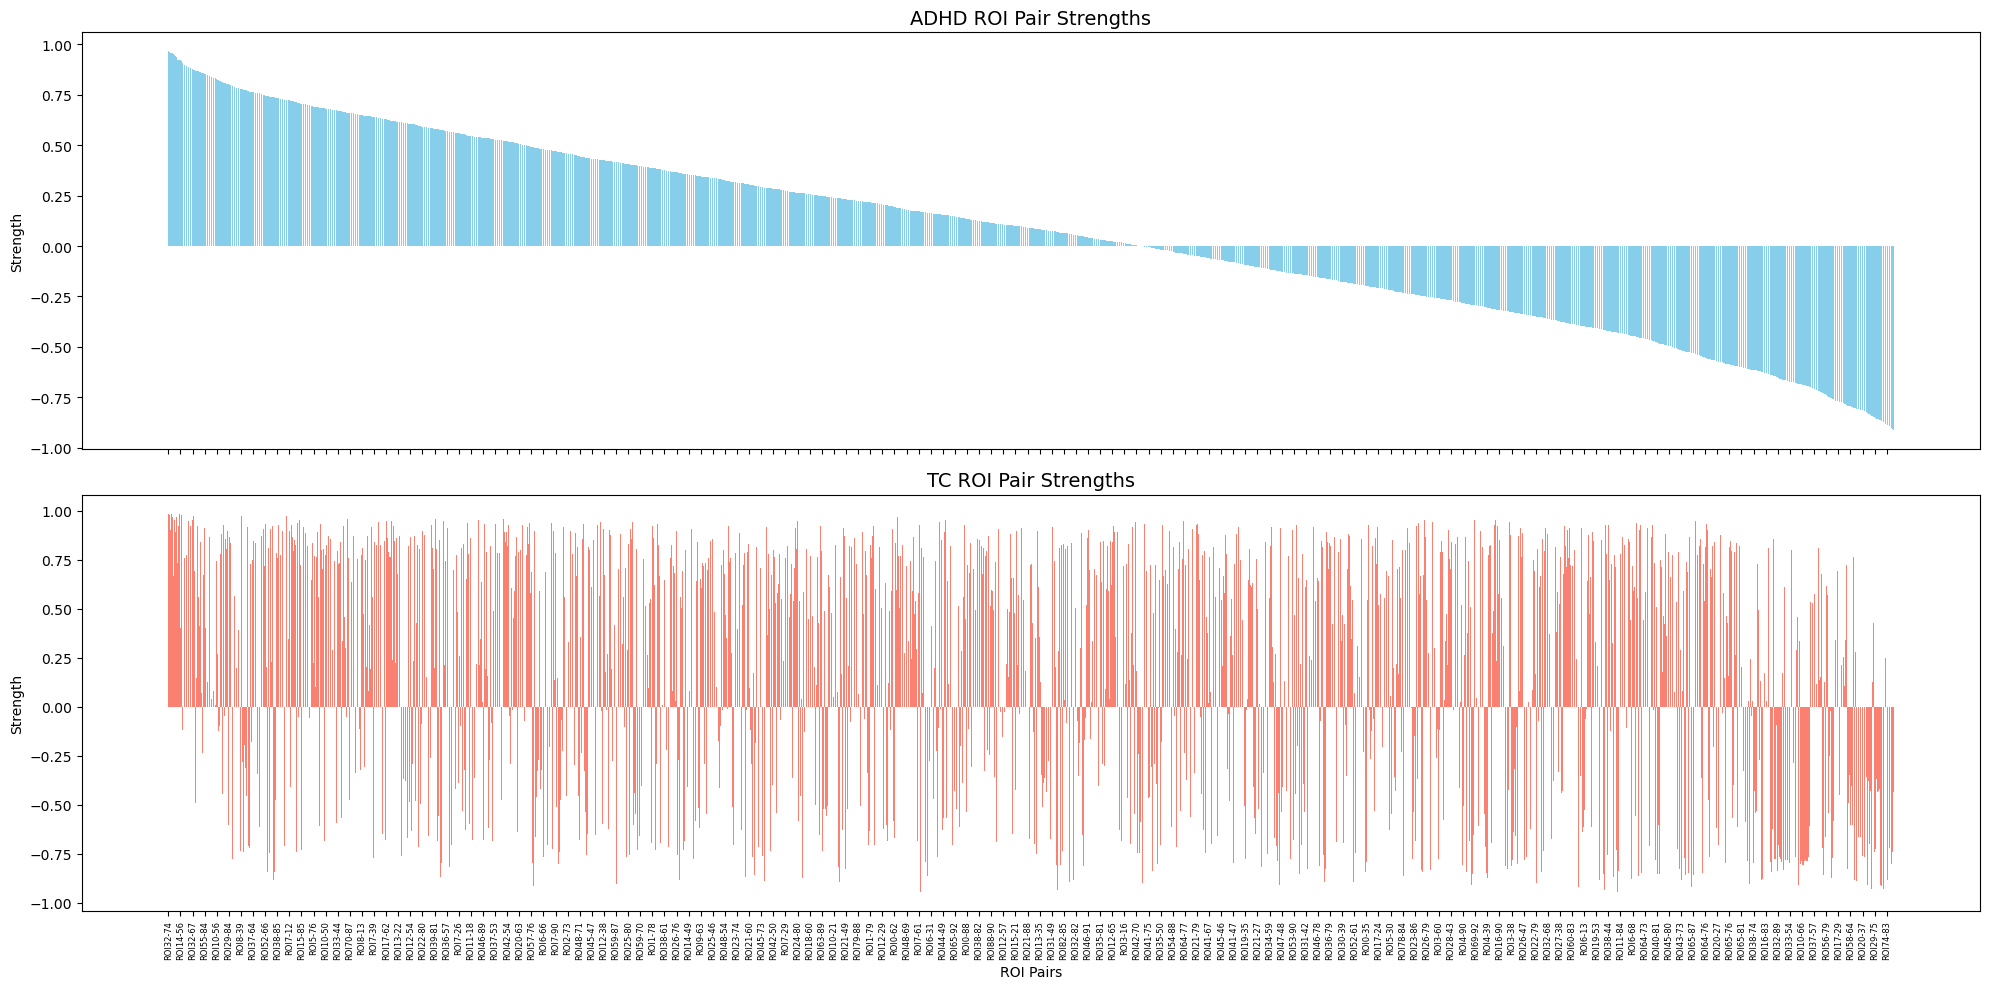

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
adhd_0 = (adhd[0] + adhd[0].T) / 2
np.fill_diagonal(adhd_0, 0)
tc_0 = (tc[0] + tc_0.T) / 2
np.fill_diagonal(tc_0, 0)

# Extract ROI pair strengths from upper triangle
roi_pairs = []
adhd_strengths = []
tc_strengths = []

for i in range(93):
    for j in range(i + 1, 93):
        roi_pairs.append(f"ROI{i}-{j}")
        adhd_strengths.append(adhd_0[i, j])
        tc_strengths.append(tc_0[i, j])

# Optional: sort by ADHD strengths
sorted_indices = np.argsort(adhd_strengths)[::-1]  # descending
roi_pairs_sorted = [roi_pairs[i] for i in sorted_indices]
adhd_sorted = [adhd_strengths[i] for i in sorted_indices]
tc_sorted = [tc_strengths[i] for i in sorted_indices]

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

axs[0].bar(range(len(roi_pairs_sorted)), adhd_sorted, color='skyblue')
axs[0].set_title("ADHD ROI Pair Strengths", fontsize=14)
axs[0].set_ylabel("Strength")

axs[1].bar(range(len(roi_pairs_sorted)), tc_sorted, color='salmon')
axs[1].set_title("TC ROI Pair Strengths", fontsize=14)
axs[1].set_ylabel("Strength")
axs[1].set_xlabel("ROI Pairs")

# Optional: add x-tick labels for every Nth pair to avoid clutter
step = 30  # change as needed
axs[1].set_xticks(range(0, len(roi_pairs_sorted), step))
axs[1].set_xticklabels(roi_pairs_sorted[::step], rotation=90, fontsize=6)

plt.tight_layout()
plt.show()


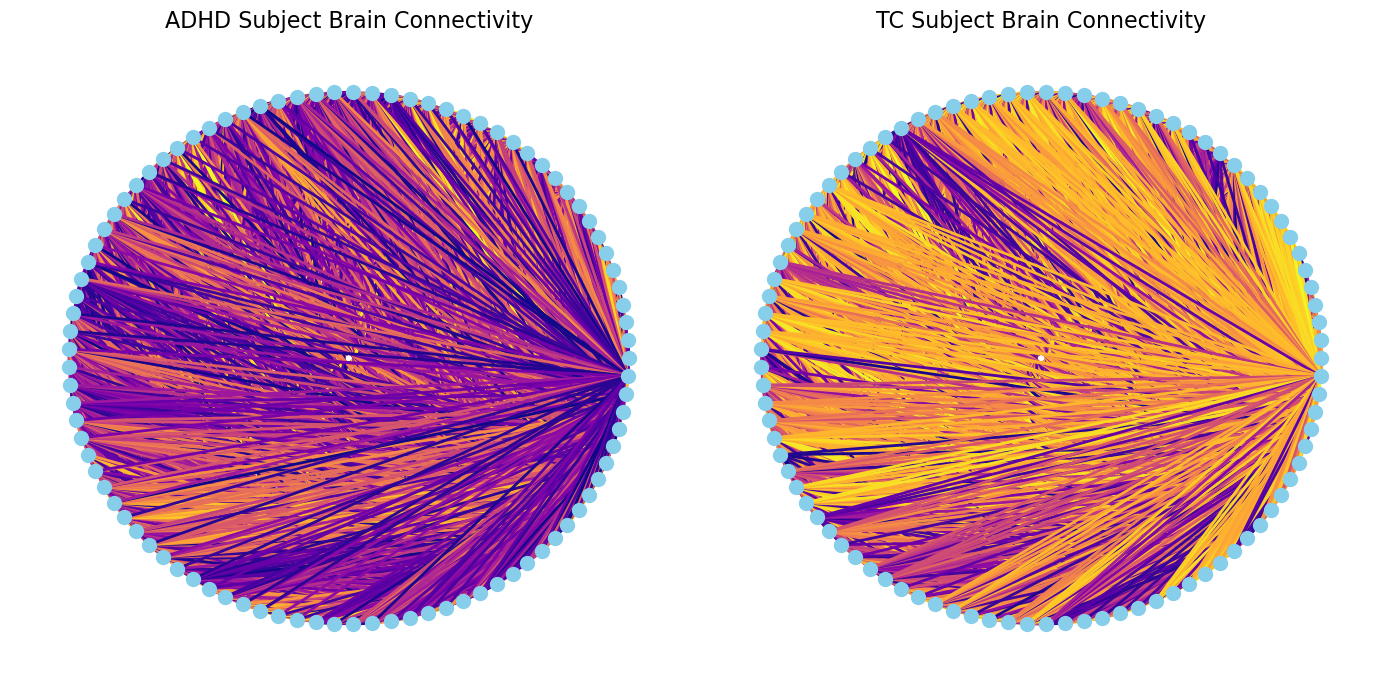

In [35]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Dummy coordinates (you can replace this with actual brain ROI locations if available)
def circular_layout(n_nodes):
    angles = np.linspace(0, 2 * np.pi, n_nodes, endpoint=False)
    return {i: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}

def plot_connectome(matrix, ax, title):
    G = nx.from_numpy_array(matrix)
    pos = circular_layout(len(matrix))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color='skyblue', ax=ax)

    # Draw edges with weights (thresholding to avoid clutter)
    edges = [(i, j) for i in range(len(matrix)) for j in range(i) if matrix[i, j] > 0.1]
    weights = [matrix[i, j] for i, j in edges]
    
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=2, edge_color=weights, edge_cmap=plt.cm.plasma, ax=ax)
    
    ax.set_title(title, fontsize=16)
    ax.axis('off')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

plot_connectome(adhd[0], ax1, 'ADHD Subject Brain Connectivity')
plot_connectome(tc[0], ax2, 'TC Subject Brain Connectivity')

plt.tight_layout()
plt.show()


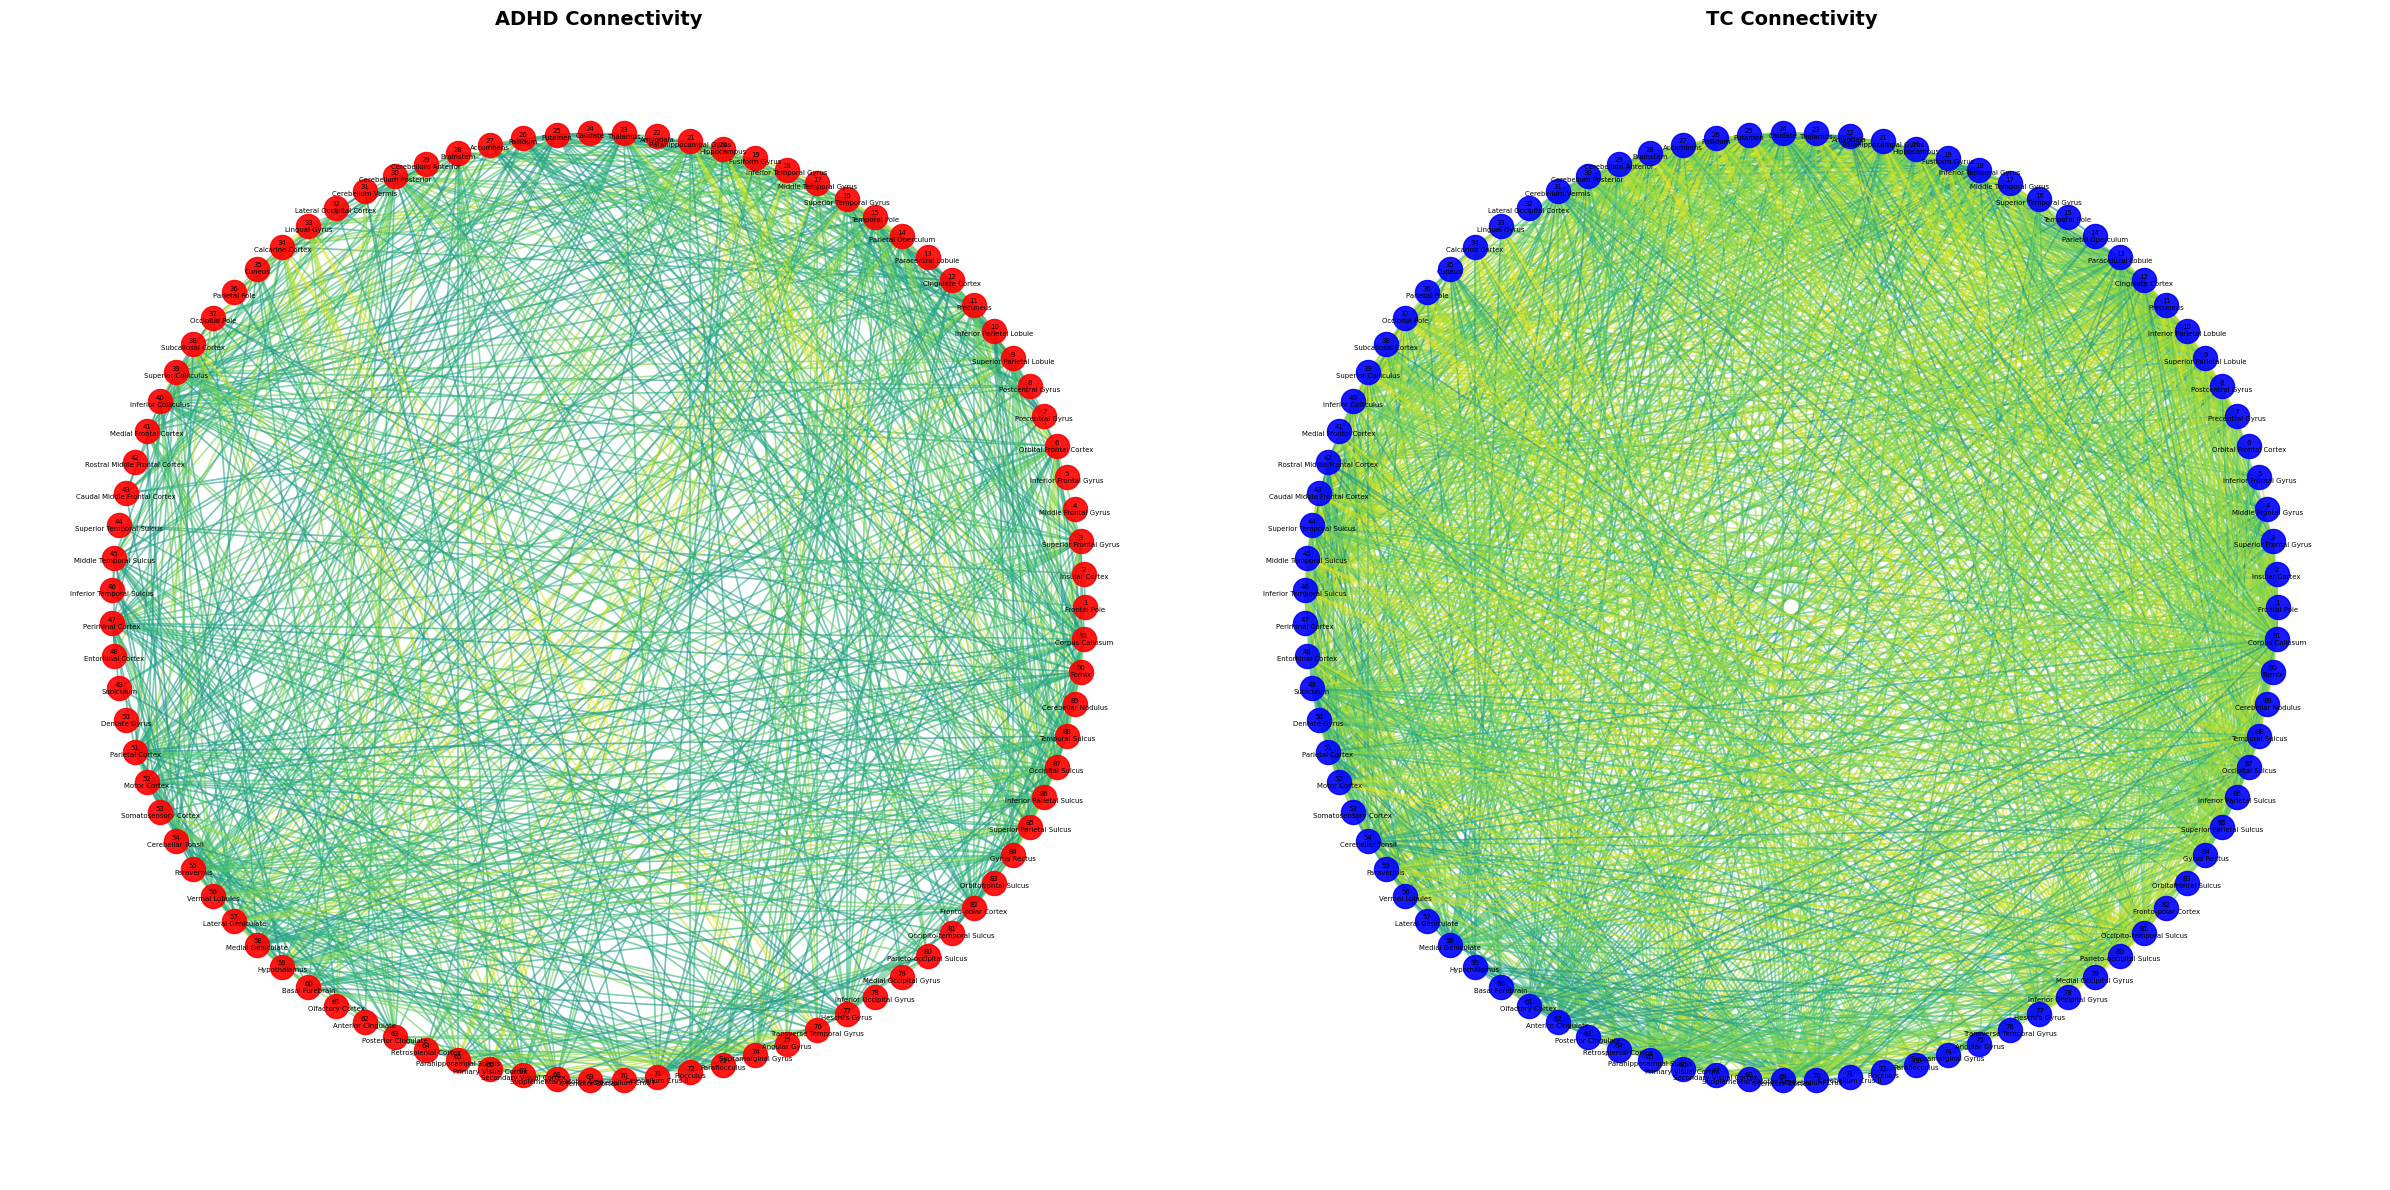

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import Normalize

# Replace these with your actual data
adhd_connectivity = adhd[0]  # Shape: (93, 93)
tc_connectivity = tc[0]      # Shape: (93, 93)

# ROI labels (must match number of ROIs in the matrix)
roi_labels = [
    "Frontal Pole", "Insular Cortex", "Superior Frontal Gyrus", "Middle Frontal Gyrus", "Inferior Frontal Gyrus",
    "Orbital Frontal Cortex", "Precentral Gyrus", "Postcentral Gyrus", "Superior Parietal Lobule", "Inferior Parietal Lobule",
    "Precuneus", "Cingulate Cortex", "Paracentral Lobule", "Parietal Operculum", "Temporal Pole",
    "Superior Temporal Gyrus", "Middle Temporal Gyrus", "Inferior Temporal Gyrus", "Fusiform Gyrus", "Hippocampus",
    "Parahippocampal Gyrus", "Amygdala", "Thalamus", "Caudate", "Putamen", "Pallidum", "Accumbens",
    "Brainstem", "Cerebellum Anterior", "Cerebellum Posterior", "Cerebellum Vermis",
    "Lateral Occipital Cortex", "Lingual Gyrus", "Calcarine Cortex", "Cuneus", "Parietal Pole",
    "Occipital Pole", "Subcallosal Cortex", "Superior Colliculus", "Inferior Colliculus",
    "Medial Frontal Cortex", "Rostral Middle Frontal Cortex", "Caudal Middle Frontal Cortex",
    "Superior Temporal Sulcus", "Middle Temporal Sulcus", "Inferior Temporal Sulcus",
    "Perirhinal Cortex", "Entorhinal Cortex", "Subiculum", "Dentate Gyrus", "Parietal Cortex",
    "Motor Cortex", "Somatosensory Cortex", "Cerebellar Tonsil", "Paravermis", "Vermal Lobules",
    "Lateral Geniculate", "Medial Geniculate", "Hypothalamus", "Basal Forebrain", "Olfactory Cortex",
    "Anterior Cingulate", "Posterior Cingulate", "Retrosplenial Cortex", "Parahippocampal Sulcus",
    "Primary Visual Cortex", "Secondary Visual Cortex", "Supplementary Motor Area", "Premotor Cortex",
    "Cerebellum Crus I", "Cerebellum Crus II", "Flocculus", "Paraflocculus",
    "Supramarginal Gyrus", "Angular Gyrus", "Transverse Temporal Gyrus",
    "Heschl's Gyrus", "Inferior Occipital Gyrus", "Medial Occipital Gyrus",
    "Parieto-occipital Sulcus", "Occipito-temporal Sulcus", "Fronto-polar Cortex",
    "Orbitofrontal Sulcus", "Gyrus Rectus", "Superior Parietal Sulcus", "Inferior Parietal Sulcus",
    "Occipital Sulcus", "Temporal Sulcus", "Cerebellar Nodulus", "Fornix", "Corpus Callosum"
]

# Ensure number of ROIs matches number of labels
num_rois = len(roi_labels)

# Plotting function
def plot_connectivity(ax, connectivity, title, node_color):
    G = nx.Graph()
    theta = np.linspace(0, 2 * np.pi, num_rois, endpoint=False)

    for i, angle in enumerate(theta):
        label = f"{i+1}\n{roi_labels[i]}"
        G.add_node(i, pos=(np.cos(angle), np.sin(angle)), label=label)

    # Normalize edge weights for color mapping
    norm = Normalize(vmin=0, vmax=np.max(connectivity))
    cmap = plt.cm.viridis

    # Add edges for weights above threshold
    for r in range(num_rois):
        for c in range(r + 1, num_rois):
            weight = connectivity[r, c]
            if weight > 0.5:
                G.add_edge(r, c, weight=weight)

    pos = nx.get_node_attributes(G, 'pos')
    labels = nx.get_node_attributes(G, 'label')
    edges = G.edges(data=True)
    edge_colors = [cmap(norm(d['weight'])) for _, _, d in edges]

    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=300, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=5, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, width=1.2, alpha=0.6, ax=ax)

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis('off')

# Create plot
fig, axs = plt.subplots(1, 2, figsize=(24, 12))
plot_connectivity(axs[0], adhd_connectivity, "ADHD Connectivity", "red")
plot_connectivity(axs[1], tc_connectivity, "TC Connectivity", "blue")

plt.tight_layout()
plt.show()


# Graph spectral

In [10]:
import numpy as np
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y=np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")

In [8]:
!pip install numpy==1.22.0

Defaulting to user installation because normal site-packages is not writeable
     --------------------------------------- 15.9/15.9 MB 31.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.4
    Uninstalling numpy-1.21.4:
      Successfully uninstalled numpy-1.21.4


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\hp\\AppData\\Roaming\\Python\\Python39\\site-packages\\~4mpy\\.libs\\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll'
Check the permissions.



In [7]:
!pip install scikit-learn

^C


In [9]:
print(np.__version__)

1.22.4


In [2]:
X.shape

(1168, 93, 93)

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, LSTM, Flatten, concatenate

n_samples = X.shape[0]
a = X.shape[1]  # Dimension of the connectivity matrices
n_classes = 2

flattened_matrices = X.reshape(n_samples, -1)
target = Y

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(a*a, 1)),
    Flatten(),
    Dense(64, activation='relu')
])

# Define LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(a*a, 1)),
    Dense(64, activation='relu')
])

# Combined input
combined_input = concatenate([cnn_model.output, lstm_model.output])

# Classification layer
output = Dense(n_classes, activation='softmax')(combined_input)

# Combined model
combined_model = Model(inputs=[cnn_model.input, lstm_model.input], outputs=output)

# Compile model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for train_index, test_index in skf.split(flattened_matrices, target):
    X_train, X_test = flattened_matrices[train_index], flattened_matrices[test_index]
    y_train, y_test = target[train_index], target[test_index]

    # Train model
    history = combined_model.fit([X_train, X_train], y_train, epochs=10, batch_size=32, verbose=0)
    
    # Evaluate model on training data
    train_loss, train_accuracy = combined_model.evaluate([X_train, X_train], y_train, verbose=0)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate model on test data
    test_loss, test_accuracy = combined_model.evaluate([X_test, X_test], y_test, verbose=0)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print("Train Accuracy:", train_accuracy, "Train Loss:", train_loss)
    print("Test Accuracy:", test_accuracy, "Test Loss:", test_loss)

# Calculate average metrics
avg_train_loss = np.mean(train_losses)
avg_train_accuracy = np.mean(train_accuracies)
avg_test_loss = np.mean(test_losses)
avg_test_accuracy = np.mean(test_accuracies)

print("Average Train Accuracy:", avg_train_accuracy, "Average Train Loss:", avg_train_loss)
print("Average Test Accuracy:", avg_test_accuracy, "Average Test Loss:", avg_test_loss)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, LSTM, Flatten, concatenate

n_samples = X.shape[0]
a = X.shape[1]  # Dimension of the connectivity matrices
n_classes = 2

flattened_matrices = X.reshape(n_samples, -1)
target = Y

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(a*a, 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu')
])

# Define LSTM model
lstm_model = Sequential([
    LSTM(32, input_shape=(a*a, 1)),
    Dense(128, activation='relu')
])

# Combined input
combined_input = concatenate([cnn_model.output, lstm_model.output])

# Classification layer
output = Dense(n_classes, activation='softmax')(combined_input)

# Combined model
combined_model = Model(inputs=[cnn_model.input, lstm_model.input], outputs=output)

combined_model.summary()
# Compile model
combined_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Perform 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for fold, (train_index, test_index) in enumerate(skf.split(flattened_matrices, target)):
    print(f"Fold {fold + 1}/{skf.get_n_splits()}:")

    X_train, X_test = flattened_matrices[train_index], flattened_matrices[test_index]
    y_train, y_test = target[train_index], target[test_index]

    # Reset model weights for each fold
    combined_model.reset_states()

    # Train model
    history = combined_model.fit([X_train, X_train], y_train, epochs=10, batch_size=28, verbose=0, validation_data=([X_test, X_test], y_test))
    
    # Print training and validation metrics for each epoch
    for epoch in range(len(history.history['accuracy'])):
        train_acc = history.history['accuracy'][epoch]
        train_loss = history.history['loss'][epoch]
        test_acc = history.history['val_accuracy'][epoch]
        test_loss = history.history['val_loss'][epoch]
        print(f"Epoch {epoch + 1}/{len(history.history['accuracy'])} - Train Accuracy: {train_acc:.4f}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    # Evaluate model on training data after all epochs
    train_loss, train_accuracy = combined_model.evaluate([X_train, X_train], y_train, verbose=0)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Evaluate model on test data after all epochs
    test_loss, test_accuracy = combined_model.evaluate([X_test, X_test], y_test, verbose=0)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Train Accuracy: {train_accuracy:.4f}, Train Loss: {train_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}\n")

# Calculate average metrics
avg_train_loss = np.mean(train_losses)
avg_train_accuracy = np.mean(train_accuracies)
avg_test_loss = np.mean(test_losses)
avg_test_accuracy = np.mean(test_accuracies)

print("Average Train Accuracy:", avg_train_accuracy, "Average Train Loss:", avg_train_loss)
print("Average Test Accuracy:", avg_test_accuracy, "Average Test Loss:", avg_test_loss)


# experiment

Fold 1/5
Model: "sequential_132"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_120 (Conv1D)         (None, 8649, 32)          128       
                                                                 
 dropout_16 (Dropout)        (None, 8649, 32)          0         
                                                                 
 max_pooling1d_21 (MaxPoolin  (None, 4324, 32)         0         
 g1D)                                                            
                                                                 
 conv1d_121 (Conv1D)         (None, 4324, 64)          6208      
                                                                 
 dropout_17 (Dropout)        (None, 4324, 64)          0         
                                                                 
 max_pooling1d_22 (MaxPoolin  (None, 2162, 64)         0         
 g1D)                                      

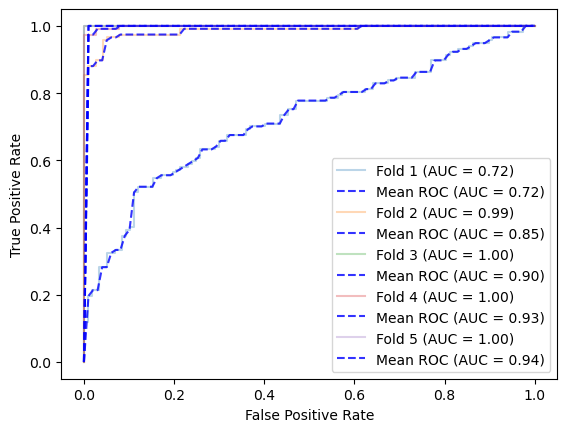

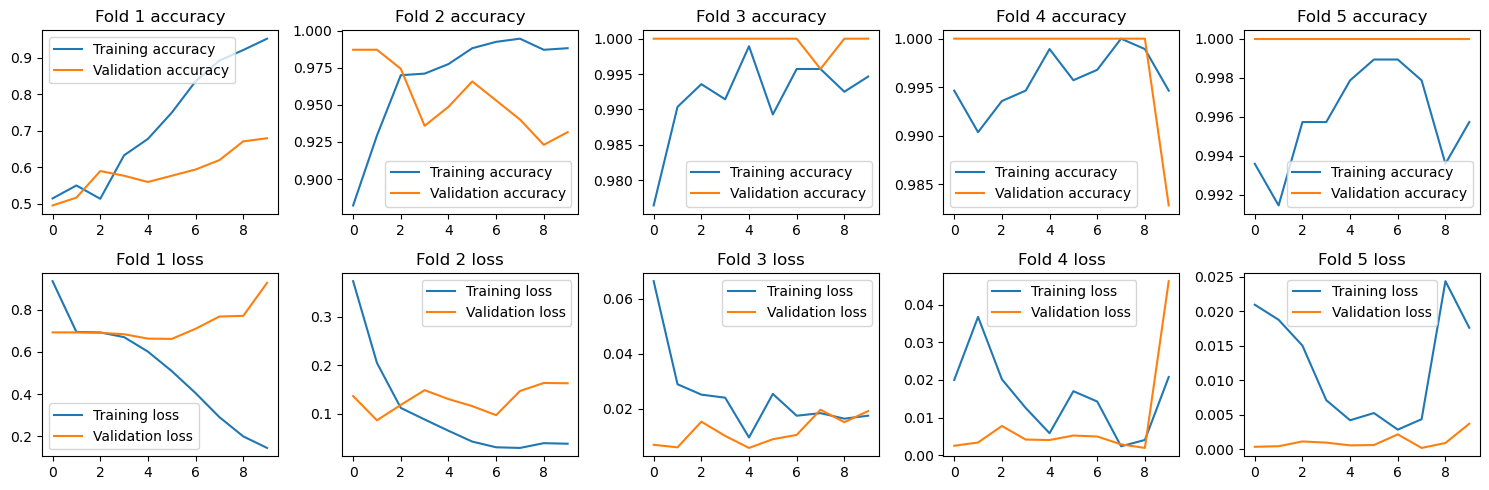

In [109]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y=np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")
X=np.reshape(X,(X.shape[0],X.shape[1]*X.shape[2]))
# Preprocess the data as needed, such as normalization or rescaling
input_shape = (X.shape[1], 1)
# Define the model architecture
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(X.shape[1], 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
# Define the k-fold cross-validation
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
# Define the lists to store the results
auc_scores = []
precisions=[]
sensitivities=[]
specificities=[]
accuracies=[]
tprs=[]

acc_scores = []
val_acc_scores = []
loss_scores = []
val_loss_scores = []

mean_fpr = np.linspace(0, 1, 100)

# Train and evaluate the model using k-fold cross-validation and ROC curves
for fold, (train_idx, val_idx) in enumerate(skf.split(X, Y)):
    print(f"Fold {fold + 1}/{k}")
    
    # Split the data into training and validation sets
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val, y_val = X[val_idx], Y[val_idx]
    
    # Reshape the data for the Conv1D layer
    X_train = np.expand_dims(X_train, axis=-1)
    X_val = np.expand_dims(X_val, axis=-1)
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    history=model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val))
    acc_scores.append(history.history['accuracy'])
    val_acc_scores.append(history.history['val_accuracy'])
    loss_scores.append(history.history['loss'])
    val_loss_scores.append(history.history['val_loss'])
    
    # Calculate the predicted probabilities and ROC curve
    y_pred_prob = model.predict(X_val)
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    auc_score = roc_auc_score(y_val, y_pred_prob)
    auc_scores.append(auc_score)
    
    # Interpolate the ROC curve to the mean FPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    y_pred = np.where(y_pred_prob > 0.5, 1, 0)
    conf_matrix = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tprs.append(tpr)
    #aucs.append(roc_auc)
    precisions.append(precision)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    accuracies.append(accuracy)
    # Plot the ROC curve
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold + 1} (AUC = {auc_score:.2f})")
    plt.plot(mean_fpr, interp_tpr, alpha=0.8, label=f"Mean ROC (AUC = {np.mean(auc_scores):.2f})", color='b', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')

#mean_tpr = np.mean(tprs, axis=0)
#std_tpr = np.std(tprs, axis=0)
mean_precision = np.mean(precisions)
std_precision = np.std(precisions)
mean_sensitivity = np.mean(sensitivities)
std_sensitivity = np.std(sensitivities)
mean_specificity = np.mean(specificity)
std_specificity = np.std(specificity)
mean_accuracy  = np.mean(accuracies)
std_accuracy  = np.std(accuracies)
    # Print the average AUC score over all folds
print(f"Mean AUC score: {np.mean(auc_scores):.2f}")
print("Precision : ", mean_precision, '(+/-)' , std_precision)
print("Sensitivity : ",mean_sensitivity, '(+/-)' , std_sensitivity)
print("Specificity : ",mean_specificity, '(+/-)' , std_specificity)
print("Accuracy : ",mean_accuracy, '(+/-)' , std_accuracy)
# Save the plot
plt.savefig('roc_curve.png')

fig, axs = plt.subplots(2, k, figsize=(15, 5))
for i in range(k):
    axs[0,i].plot(acc_scores[i], label='Training accuracy')
    axs[0,i].plot(val_acc_scores[i], label='Validation accuracy')
    axs[0,i].set_title(f'Fold {i+1} accuracy')
    axs[0,i].legend()
    axs[1,i].plot(loss_scores[i], label='Training loss')
    axs[1,i].plot(val_loss_scores[i], label='Validation loss')
    axs[1,i].set_title(f'Fold {i+1} loss')
    axs[1,i].legend()

plt.tight_layout()
plt.show()

In [ ]:
X=np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y=np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

X = np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y = np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")
X = np.reshape(X, (X.shape[0], X.shape[1]*X.shape[2]))

# Define the model architecture
def create_model(input_shape):
    model_cnn = tf.keras.Sequential([
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Flatten()
    ])

    model_lstm = tf.keras.Sequential([
        tf.keras.layers.LSTM(32, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Flatten()
    ])

    combined_input = tf.keras.layers.concatenate([model_cnn.output, model_lstm.output])
    x = tf.keras.layers.Dense(64, activation='relu')(combined_input)
    x = tf.keras.layers.Dropout(0.2)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=[model_cnn.input, model_lstm.input], outputs=output)
    return model

# Define the k-fold cross-validation
k = 2
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Define the lists to store the results
auc_scores = []
precisions=[]
sensitivities=[]
specificities=[]
accuracies=[]
tprs=[]

acc_scores = []
val_acc_scores = []
loss_scores = []
val_loss_scores = []

mean_fpr = np.linspace(0, 1, 100)

# Train and evaluate the model using k-fold cross-validation and ROC curves
for fold, (train_idx, val_idx) in enumerate(skf.split(X, Y)):
    print(f"Fold {fold + 1}/{k}")

    # Split the data into training and validation sets
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val, y_val = X[val_idx], Y[val_idx]

    # Reshape the data for the Conv1D layer
    X_train = np.expand_dims(X_train, axis=-1)
    X_val = np.expand_dims(X_val, axis=-1)

    model = create_model(input_shape=(X.shape[1], 1))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()

    history = model.fit([X_train, X_train], y_train, epochs=1, batch_size=8, validation_data=([X_val, X_val], y_val))

    acc_scores.append(history.history['accuracy'])
    val_acc_scores.append(history.history['val_accuracy'])
    loss_scores.append(history.history['loss'])
    val_loss_scores.append(history.history['val_loss'])
    
    # Calculate the predicted probabilities and ROC curve
    y_pred_prob = model.predict([X_val, X_val])
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    auc_score = roc_auc_score(y_val, y_pred_prob)
    auc_scores.append(auc_score)
    
    # Interpolate the ROC curve to the mean FPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    y_pred = np.where(y_pred_prob > 0.5, 1, 0)
    conf_matrix = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tprs.append(tpr)
    #aucs.append(roc_auc)
    precisions.append(precision)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    accuracies.append(accuracy)
    # Plot the ROC curve
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold + 1} (AUC = {auc_score:.2f})")
    plt.plot(mean_fpr, interp_tpr, alpha=0.8, label=f"Mean ROC (AUC = {np.mean(auc_scores):.2f})", color='b', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')

#mean_tpr = np.mean(tprs, axis=0)
#std_tpr = np.std(tprs, axis=0)
mean_precision = np.mean(precisions)
std_precision = np.std(precisions)
mean_sensitivity = np.mean(sensitivities)
std_sensitivity = np.std(sensitivities)
mean_specificity = np.mean(specificity)
std_specificity = np.std(specificity)
mean_accuracy  = np.mean(accuracies)
std_accuracy  = np.std(accuracies)
    # Print the average AUC score over all folds
print(f"Mean AUC score: {np.mean(auc_scores):.2f}")
print("Precision : ", mean_precision, '(+/-)' , std_precision)
print("Sensitivity : ",mean_sensitivity, '(+/-)' , std_sensitivity)
print("Specificity : ",mean_specificity, '(+/-)' , std_specificity)
print("Accuracy : ",mean_accuracy, '(+/-)' , std_accuracy)
# Save the plot
plt.savefig('roc_curve.png')

fig, axs = plt.subplots(2, k, figsize=(15, 5))
for i in range(k):
    axs[0,i].plot(acc_scores[i], label='Training accuracy')
    axs[0,i].plot(val_acc_scores[i], label='Validation accuracy')
    axs[0,i].set_title(f'Fold {i+1} accuracy')
    axs[0,i].legend()
    axs[1,i].plot(loss_scores[i], label='Training loss')
    axs[1,i].plot(val_loss_scores[i], label='Validation loss')
    axs[1,i].set_title(f'Fold {i+1} loss')
    axs[1,i].legend()

plt.tight_layout()
plt.show()


In [36]:
X = np.load("E:/ADHD_EXP/unni/upsampled_ICA+DL_threshold_0.1178_power_8.npy")
Y = np.load("E:/ADHD_EXP/unni/upsampled_labels_1168.npy")


In [37]:
X.shape

(1168, 93, 93)

In [38]:
tri_upper_indices = np.triu_indices(n=X.shape[1])

# Use these indices to select the upper triangular parts and flatten them
X_flattened_upper = np.array([x[tri_upper_indices] for x in X])

# Now, X_flattened_upper should have the shape (1168, 4365)
print("New shape of X:", X_flattened_upper.shape)

New shape of X: (1168, 4371)


In [39]:
X=X_flattened_upper

In [ ]:
X = np.reshape(X, (X.shape[0], X.shape[1]*X.shape[2]))

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X= scaler.fit_transform(X)
from sklearn.decomposition import PCA
pca = PCA(n_components = 0.90)
X = pca.fit_transform(X)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, Conv1D, MaxPooling1D, Flatten, concatenate, Permute, Reshape, Multiply
from tensorflow.keras.models import Model





def create_model(input_shape):
    input_cnn = Input(shape=input_shape)
    cnn = Conv1D(filters=8, kernel_size=3, activation='relu', padding='same')(input_cnn)
    cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(cnn)
    cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(cnn)
    cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = Flatten()(cnn)

    input_lstm = Input(shape=input_shape)
    lstm = LSTM(32, return_sequences=True)(input_lstm)
    lstm = LSTM(64)(lstm)
    lstm = Flatten()(lstm)

    combined = concatenate([cnn, lstm])

    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[input_cnn, input_lstm], outputs=output)
    return model
# Define the k-fold cross-validation
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Define the lists to store the results
auc_scores = []
precisions=[]
sensitivities=[]
specificities=[]
accuracies=[]
tprs=[]

acc_scores = []
val_acc_scores = []
loss_scores = []
val_loss_scores = []

mean_fpr = np.linspace(0, 1, 100)

# Train and evaluate the model using k-fold cross-validation and ROC curves
for fold, (train_idx, val_idx) in enumerate(skf.split(X, Y)):
    print(f"Fold {fold + 1}/{k}")

    # Split the data into training and validation sets
    X_train, y_train = X[train_idx], Y[train_idx]
    X_val, y_val = X[val_idx], Y[val_idx]

    # Reshape the data for the Conv1D layer
    X_train = np.expand_dims(X_train, axis=-1)
    X_val = np.expand_dims(X_val, axis=-1)

    model = create_model(input_shape=(X.shape[1], 1))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()

    history = model.fit([X_train, X_train], y_train, epochs=20, batch_size=8, validation_data=([X_val, X_val], y_val))

    acc_scores.append(history.history['accuracy'])
    val_acc_scores.append(history.history['val_accuracy'])
    loss_scores.append(history.history['loss'])
    val_loss_scores.append(history.history['val_loss'])
    
    # Calculate the predicted probabilities and ROC curve
    y_pred_prob = model.predict([X_val, X_val])
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    auc_score = roc_auc_score(y_val, y_pred_prob)
    auc_scores.append(auc_score)
    
    # Interpolate the ROC curve to the mean FPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    y_pred = np.where(y_pred_prob > 0.5, 1, 0)
    conf_matrix = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    precision = tp / (tp + fp)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    tprs.append(tpr)
    #aucs.append(roc_auc)
    precisions.append(precision)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    accuracies.append(accuracy)
    # Plot the ROC curve
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold + 1} (AUC = {auc_score:.2f})")
    plt.plot(mean_fpr, interp_tpr, alpha=0.8, label=f"Mean ROC (AUC = {np.mean(auc_scores):.2f})", color='b', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')

#mean_tpr = np.mean(tprs, axis=0)
#std_tpr = np.std(tprs, axis=0)
mean_precision = np.mean(precisions)
std_precision = np.std(precisions)
mean_sensitivity = np.mean(sensitivities)
std_sensitivity = np.std(sensitivities)
mean_specificity = np.mean(specificity)
std_specificity = np.std(specificity)
mean_accuracy  = np.mean(accuracies)
std_accuracy  = np.std(accuracies)
    # Print the average AUC score over all folds
print(f"Mean AUC score: {np.mean(auc_scores):.2f}")
print("Precision : ", mean_precision, '(+/-)' , std_precision)
print("Sensitivity : ",mean_sensitivity, '(+/-)' , std_sensitivity)
print("Specificity : ",mean_specificity, '(+/-)' , std_specificity)
print("Accuracy : ",mean_accuracy, '(+/-)' , std_accuracy)
# Save the plot
plt.savefig('roc_curve.png')

fig, axs = plt.subplots(2, k, figsize=(15, 5))
for i in range(k):
    axs[0,i].plot(acc_scores[i], label='Training accuracy')
    axs[0,i].plot(val_acc_scores[i], label='Validation accuracy')
    axs[0,i].set_title(f'Fold {i+1} accuracy')
    axs[0,i].legend()
    axs[1,i].plot(loss_scores[i], label='Training loss')
    axs[1,i].plot(val_loss_scores[i], label='Validation loss')
    axs[1,i].set_title(f'Fold {i+1} loss')
    axs[1,i].legend()

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
X=np.load("D:/adhd_riemann_manifold_threshold_2.2507_power_2.npy")
X

array([[152494.73465116, 152495.77713656, 152495.78310202, ...,
        152495.77146591, 152495.77278019, 152495.77767851],
       [153228.34030825, 153229.80061561, 153228.32857137, ...,
        153228.3235413 , 153228.33066894, 153228.33433197],
       [277362.61290052, 277362.59818101, 277364.72779446, ...,
        277362.5759121 , 277362.58064556, 277362.58680194],
       ...,
       [257179.39132952, 257179.37649529, 257179.35548799, ...,
        257182.97228655, 257179.36521328, 257179.37421187],
       [216743.80037257, 216743.78972379, 216743.77040059, ...,
        216743.77254565, 216746.26430427, 216743.78122212],
       [172109.96304144, 172109.95696863, 172109.94673344, ...,
        172109.94507684, 172109.94297125, 172110.99282112]])

In [7]:
X=np.load("D:/adhd_mean_gsp_combined_threshold_2.2507_power_2.npy")
X

array([[1.        , 0.85389448, 0.6332888 , ..., 0.71314405, 0.73656148,
        0.71954127],
       [0.85389448, 1.        , 0.63609168, ..., 0.74128572, 0.68061037,
        0.69425059],
       [0.6332888 , 0.63609168, 1.        , ..., 0.60169421, 0.61408097,
        0.61591242],
       ...,
       [0.71314405, 0.74128572, 0.60169421, ..., 1.        , 0.66621946,
        0.69031701],
       [0.73656148, 0.68061037, 0.61408097, ..., 0.66621946, 1.        ,
        0.80083686],
       [0.71954127, 0.69425059, 0.61591242, ..., 0.69031701, 0.80083686,
        1.        ]])

In [12]:
X=np.load("D:/adhd_mean_gsp_combined_threshold_2.2507_power_8.npy")
X

array([[1.        , 0.85389448, 0.6332888 , ..., 0.71314405, 0.73656148,
        0.71954127],
       [0.85389448, 1.        , 0.63609168, ..., 0.74128572, 0.68061037,
        0.69425059],
       [0.6332888 , 0.63609168, 1.        , ..., 0.60169421, 0.61408097,
        0.61591242],
       ...,
       [0.71314405, 0.74128572, 0.60169421, ..., 1.        , 0.66621946,
        0.69031701],
       [0.73656148, 0.68061037, 0.61408097, ..., 0.66621946, 1.        ,
        0.80083686],
       [0.71954127, 0.69425059, 0.61591242, ..., 0.69031701, 0.80083686,
        1.        ]])